In [52]:
import os
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from sklearn.metrics import classification_report, confusion_matrix 
print("TensorFlow version:", tf.__version__) 
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: True


In [53]:
# set paths and explore data
DATA_DIR = "/kaggle/input/datasets/nilesh789/eurosat-rgb"
IMG_SIZE = 64 
BATCH_SIZE = 32
EPOCHS = 20

# LIST THE CLASSES
classes = sorted(os.listdir(DATA_DIR))
print("classes found:", classes)
print("Number of classes:", len(classes))

# count images per class for cls in classes
for cls in classes:
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f" {cls}: {count} images") 

classes found: ['2750']
Number of classes: 1
 2750: 10 images


In [54]:
import os

# Find the real dataset path
base = "/kaggle/input/datasets/nilesh789/eurosat-rgb"
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        if level == 2:
            print(f"{indent}  → {len(files)} files")

eurosat-rgb/
  2750/
    SeaLake/
      → 3000 files
    Highway/
      → 2500 files
    River/
      → 2500 files
    Pasture/
      → 2000 files
    Industrial/
      → 2500 files
    Residential/
      → 3000 files
    PermanentCrop/
      → 2500 files
    AnnualCrop/
      → 3000 files
    Forest/
      → 3000 files
    HerbaceousVegetation/
      → 3000 files


In [55]:
import os
base = "/kaggle/input/datasets/nilesh789/eurosat-rgb"
print("Level 1:", os.listdir(base))
sub = os.path.join(base, os.listdir(base)[0])
print("Level 2:", os.listdir(sub))

Level 1: ['2750']
Level 2: ['SeaLake', 'Highway', 'River', 'Pasture', 'Industrial', 'Residential', 'PermanentCrop', 'AnnualCrop', 'Forest', 'HerbaceousVegetation']


In [56]:
# Cell 2: Set paths and explore data
import os

# Auto-find the folder that contains the 10 class subfolders
base = "/kaggle/input/datasets/nilesh789/eurosat-rgb"
DATA_DIR = base
for root, dirs, files in os.walk(base):
    if len(dirs) == 10:
        DATA_DIR = root
        break

print("DATA_DIR:", DATA_DIR)

IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 20

classes = sorted(os.listdir(DATA_DIR))
print("Classes found:", classes)
print("Number of classes:", len(classes))

for cls in classes:
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f"  {cls}: {count} images")

DATA_DIR: /kaggle/input/datasets/nilesh789/eurosat-rgb/2750
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10
  AnnualCrop: 3000 images
  Forest: 3000 images
  HerbaceousVegetation: 3000 images
  Highway: 2500 images
  Industrial: 2500 images
  Pasture: 2000 images
  PermanentCrop: 2500 images
  Residential: 3000 images
  River: 2500 images
  SeaLake: 3000 images


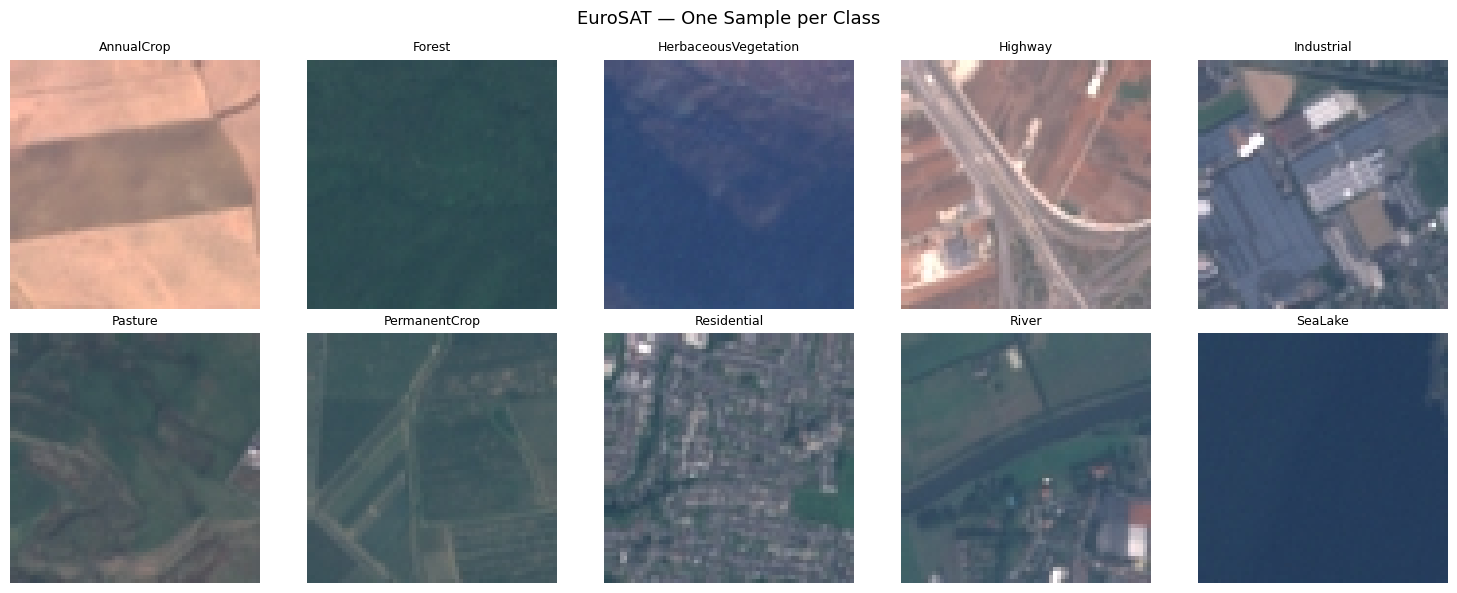

Sample images saved!


In [57]:
# Cell 3: Visualize one sample image from each class
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(classes):
    class_dir = os.path.join(DATA_DIR, cls)
    img_path = os.path.join(class_dir, os.listdir(class_dir)[0])
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

plt.suptitle("EuroSAT — One Sample per Class", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved!")

In [58]:
# Cell 4: Preprocessing and data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = test_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("Training samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)
print("Classes:", train_gen.class_indices)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
Training samples: 21600
Validation samples: 5400
Classes: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [59]:
# Cell 5: Build custom CNN model
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn(num_classes):
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn(len(classes))
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,388,906 (9.11 MB)

 Trainable params: 2,387,946 (9.11 MB)

 Non-trainable params: 960 (3.75 KB)

In [60]:
# Cell 6: Train the CNN model
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Training CNN model... please wait ~10-15 minutes")
cnn_history = cnn_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
print("Training complete!")
print(f"Best validation accuracy: {max(cnn_history.history['val_accuracy']):.4f}")

Training CNN model... please wait ~10-15 minutes
Epoch 1/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 69s 90ms/step - accuracy: 0.6189 - loss: 1.1110 - val_accuracy: 0.4820 - val_loss: 1.7185 - learning_rate: 0.0010
Epoch 2/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accuracy: 0.7663 - loss: 0.6781 - val_accuracy: 0.5431 - val_loss: 1.6649 - learning_rate: 0.0010
Epoch 3/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 56s 83ms/step - accuracy: 0.8137 - loss: 0.5522 - val_accuracy: 0.4891 - val_loss: 1.8415 - learning_rate: 0.0010
Epoch 4/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 57s 84ms/step - accuracy: 0.8452 - loss: 0.4650 - val_accuracy: 0.7122 - val_loss: 1.1054 - learning_rate: 0.0010
Epoch 5/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 56s 84ms/step - accuracy: 0.8684 - loss: 0.3957 - val_accuracy: 0.7693 - val_loss: 0.7432 - learning_rate: 0.0010
Epoch 6/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 57s 84ms/step - accuracy: 0.8817 - loss: 0.3485 - val_accuracy: 0.6207 - val_loss: 1.7134 - learning_rate: 0.0010
Epoch 7/20
675/675 ━━━━━━━━

In [61]:
# Cell 7: Transfer learning with ResNet50
base_model = keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False
 
tl_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='softmax')
])

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ResNet50... please wait ~10 minutes")
tl_history = tl_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
print("Transfer learning training complete!")
print(f"Best validation accuracy: {max(tl_history.history['val_accuracy']):.4f}")

Training ResNet50... please wait ~10 minutes
Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 75s 95ms/step - accuracy: 0.2520 - loss: 2.0469 - val_accuracy: 0.3941 - val_loss: 1.7776 - learning_rate: 0.0010
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 59s 87ms/step - accuracy: 0.3495 - loss: 1.7536 - val_accuracy: 0.4519 - val_loss: 1.5913 - learning_rate: 0.0010
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 64s 95ms/step - accuracy: 0.3849 - loss: 1.6532 - val_accuracy: 0.4502 - val_loss: 1.5434 - learning_rate: 0.0010
Epoch 4/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - accuracy: 0.4127 - loss: 1.5850 - val_accuracy: 0.4872 - val_loss: 1.4829 - learning_rate: 5.0000e-04
Epoch 5/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 59s 88ms/step - accuracy: 0.4239 - loss: 1.5617 - val_accuracy: 0.4781 - val_loss: 1.4823 - learning_rate: 5.0000e-04
Transfer learning training complete!
Best validation accuracy: 0.4872


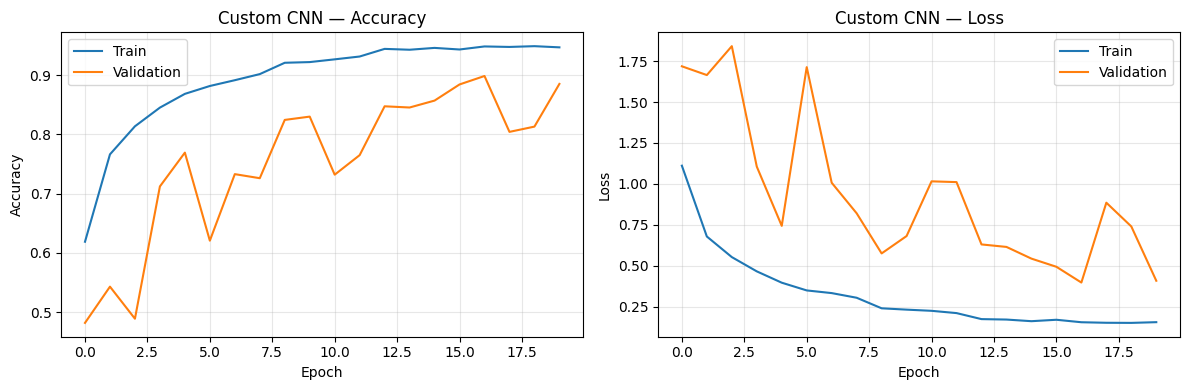

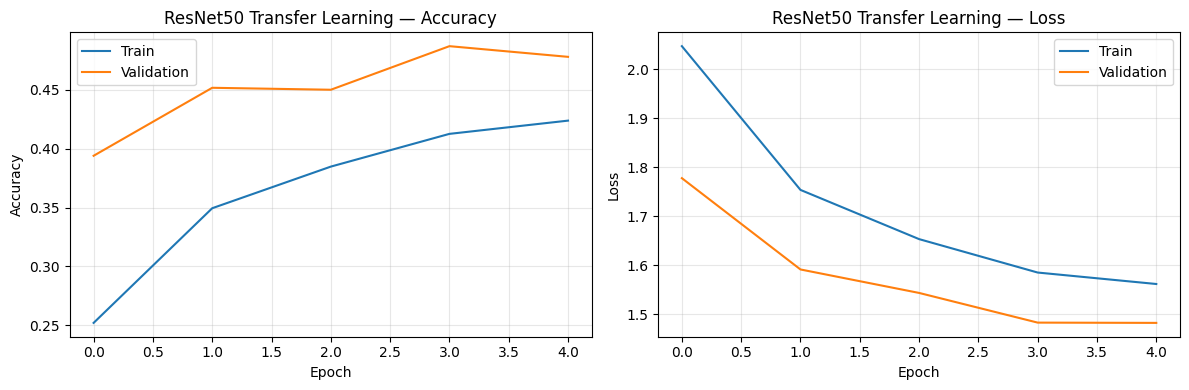

Curves saved!


In [63]:
# Cell 8: Plot accuracy and loss curves for both models
import matplotlib.pyplot as plt

def plot_history(history, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(cnn_history, "Custom CNN", "cnn_curves.png")
plot_history(tl_history, "ResNet50 Transfer Learning", "tl_curves.png")
print("Curves saved!")

169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step


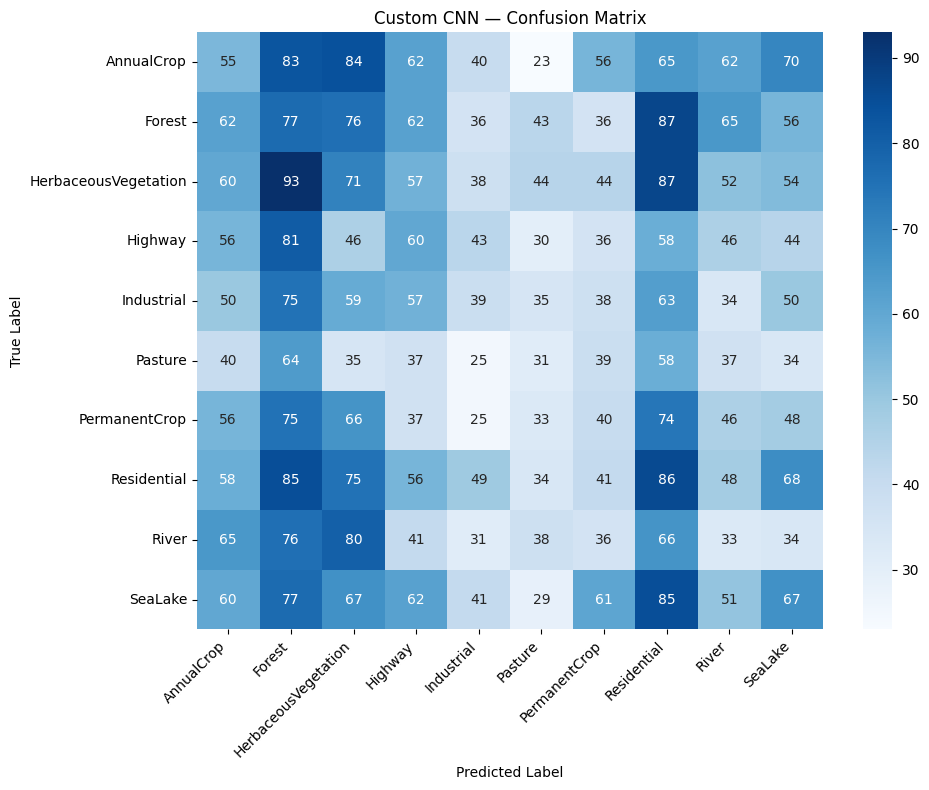

=== Custom CNN Classification Report ===
                      precision    recall  f1-score   support

          AnnualCrop       0.10      0.09      0.09       600
              Forest       0.10      0.13      0.11       600
HerbaceousVegetation       0.11      0.12      0.11       600
             Highway       0.11      0.12      0.12       500
          Industrial       0.11      0.08      0.09       500
             Pasture       0.09      0.08      0.08       400
       PermanentCrop       0.09      0.08      0.09       500
         Residential       0.12      0.14      0.13       600
               River       0.07      0.07      0.07       500
             SeaLake       0.13      0.11      0.12       600

            accuracy                           0.10      5400
           macro avg       0.10      0.10      0.10      5400
        weighted avg       0.10      0.10      0.10      5400



In [50]:
# Cell 9: Confusion matrix and classification report
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels
val_gen.reset()
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# CNN predictions
val_gen.reset()
y_pred_cnn = cnn_model.predict(val_gen, verbose=1)
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)

# Confusion matrix for CNN
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_cnn_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Custom CNN — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("=== Custom CNN Classification Report ===")
print(classification_report(y_true, y_pred_cnn_labels, target_names=class_names))

Found 5400 images belonging to 10 classes.
Getting CNN predictions...
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step


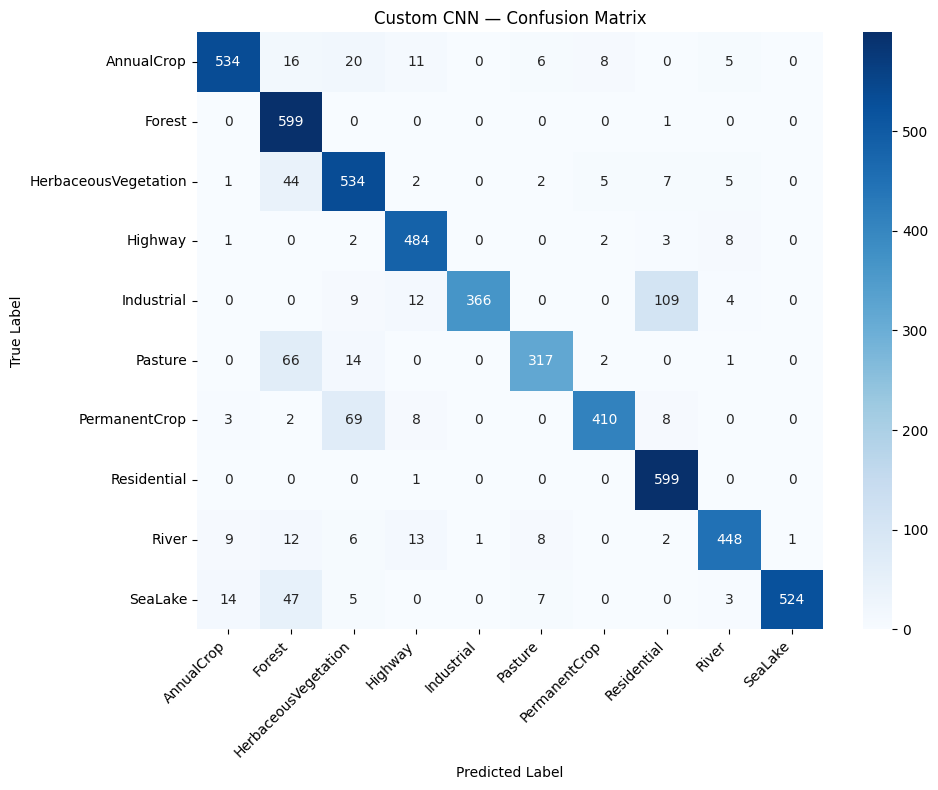

=== Custom CNN Classification Report ===
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.89      0.92       600
              Forest       0.76      1.00      0.86       600
HerbaceousVegetation       0.81      0.89      0.85       600
             Highway       0.91      0.97      0.94       500
          Industrial       1.00      0.73      0.84       500
             Pasture       0.93      0.79      0.86       400
       PermanentCrop       0.96      0.82      0.88       500
         Residential       0.82      1.00      0.90       600
               River       0.95      0.90      0.92       500
             SeaLake       1.00      0.87      0.93       600

            accuracy                           0.89      5400
           macro avg       0.91      0.89      0.89      5400
        weighted avg       0.90      0.89      0.89      5400



In [51]:
# Cell 9 FIXED: Confusion matrix and classification report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Rebuild val generator with shuffle=False so labels stay in order
val_gen_fixed = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
).flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(val_gen_fixed.class_indices.keys())

# Get true labels
y_true = val_gen_fixed.classes

# CNN predictions
print("Getting CNN predictions...")
y_pred_cnn = cnn_model.predict(val_gen_fixed, verbose=1)
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)

# Confusion matrix
plt.figure(figsize=(10, 8))
cm_matrix = confusion_matrix(y_true, y_pred_cnn_labels)
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Custom CNN — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("=== Custom CNN Classification Report ===")
print(classification_report(y_true, y_pred_cnn_labels, target_names=class_names))

         FINAL MODEL COMPARISON
  Custom CNN          : 89.85% accuracy
  ResNet50 Transfer   : 48.72% accuracy
  Winner: Custom CNN


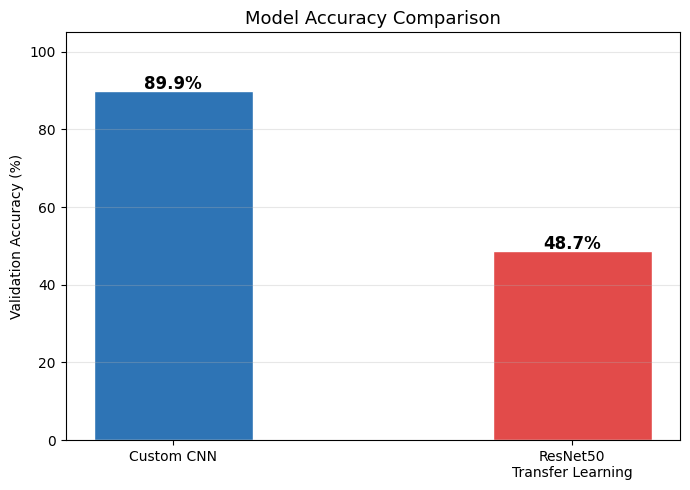

<Sequential name=sequential_7, built=True>

In [64]:
# Cell 10: Model comparison and save
import matplotlib.pyplot as plt

cnn_acc = max(cnn_history.history['val_accuracy'])
tl_acc  = max(tl_history.history['val_accuracy'])

# Print comparison table
print("=" * 50)
print("         FINAL MODEL COMPARISON")
print("=" * 50)
print(f"  Custom CNN          : {cnn_acc*100:.2f}% accuracy")
print(f"  ResNet50 Transfer   : {tl_acc*100:.2f}% accuracy")
print("=" * 50)
print(f"  Winner: {'Custom CNN' if cnn_acc > tl_acc else 'ResNet50'}")

# Bar chart comparison
models = ['Custom CNN', 'ResNet50\nTransfer Learning']
accuracies = [cnn_acc * 100, tl_acc * 100]
colors = ['#2E74B5', '#E24B4A']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.4, edgecolor='white')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=13)
plt.ylabel('Validation Accuracy (%)')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Save both models
cnn_model.save("custom_cnn_model.keras")
tl_model
